In [8]:
import gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
env = gym.make('Blackjack-v1')
num_episodes = 500000
learning_rate = 0.1
discount_factor = 0.99
epsilon = 0.1

In [3]:
env.observation_space

Tuple(Discrete(32), Discrete(11), Discrete(2))

In [4]:
env.action_space

Discrete(2)

In [5]:
env.reset()

((12, 3, False), {})

In [6]:
# Q 테이블 초기화
Q_table = np.zeros((32, 11, 2, 2))
episode_rewards = []
bet_amount = 100

## Q learning with epsilon greedy


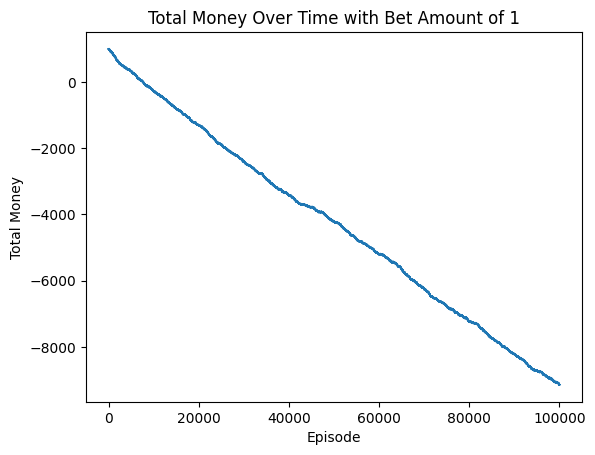

In [ ]:
import numpy as np
import gym
import matplotlib.pyplot as plt
from collections import defaultdict


class QLearningAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.99, epsilon=0.1, bet_amount=1, initial_money=10000):
        self.env = env
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.bet_amount = bet_amount
        self.initial_money = initial_money

        self.Q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.episode_rewards = []
        self.money_over_time = [initial_money]

    def choose_action(self, state):
        # Epsilon-greedy 정책에 따른 행동 선택
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.Q_values[state]))

    def update_Q_values(self, state, action, reward, next_state, done):
        future_q_value = 0 if done else np.max(self.Q_values[next_state])

        td_target = reward + self.discount_factor * future_q_value
        td_error = td_target - self.Q_values[state][action]
        self.Q_values[state][action] += self.learning_rate * td_error

    def train(self, num_episodes):
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state)
                next_state, reward, done, _, _ = self.env.step(action)

                # 베팅 금액 반영
                reward *= self.bet_amount
                total_reward += reward

                # Q-values 업데이트
                self.update_Q_values(state, action, reward, next_state, done)

                # 다음 상태로 이동
                state = next_state

            # 에피소드가 끝난 후 자금 변화 추적
            current_money = self.money_over_time[-1] + total_reward
            self.money_over_time.append(current_money)
            self.episode_rewards.append(total_reward)

        # 자금 변화 시각화
        self.plot_results(num_episodes)

    def plot_results(self, num_episodes):
        plt.plot(range(num_episodes + 1), self.money_over_time)
        plt.xlabel('Episode')
        plt.ylabel('Total Money')
        plt.title(
            f'Total Money Over Time with Bet Amount of {self.bet_amount}')
        plt.show()


env = gym.make('Blackjack-v1')

agent = QLearningAgent(env, learning_rate=0.1, discount_factor=0.99, epsilon=0.1,
                       bet_amount=1, initial_money=1000)
agent.train(num_episodes=100000)

## Q learning with decay epsilon greedy
